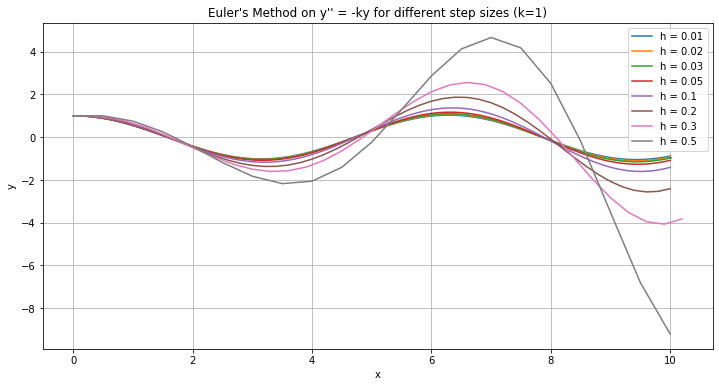

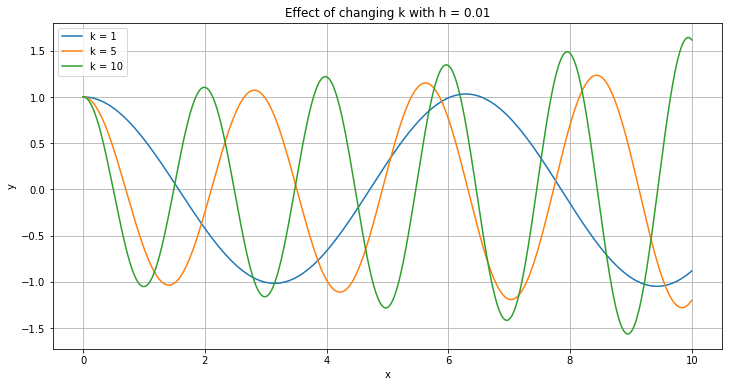

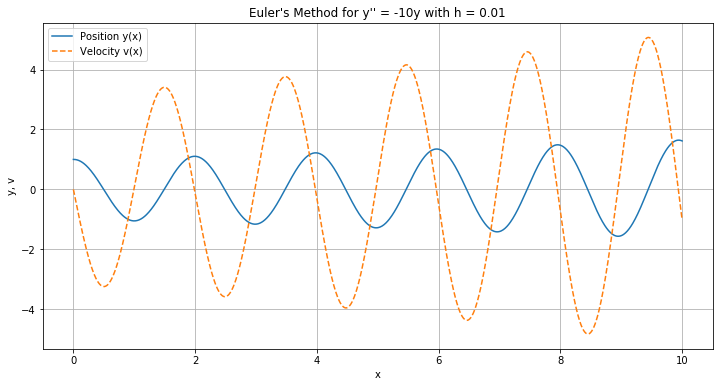

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def euler_oscillator(k, h, x_start=0, x_end=10, y0=1.0, v0=0.0):
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    y_values[0] = y0
    v_values[0] = v0

    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Euler updates
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return x_values, y_values, v_values

k = 1.0
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(12, 6))

for h in h_values:
    x, y, v = euler_oscillator(k, h)
    plt.plot(x, y, label=f'h = {h}')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method on y'' = -ky for different step sizes (k=1)")
plt.legend()
plt.grid(True)
plt.show()

k_values = [1, 5, 10]
h = 0.01

plt.figure(figsize=(12, 6))

for k in k_values:
    x, y, v = euler_oscillator(k, h)
    plt.plot(x, y, label=f'k = {k}')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Effect of changing k with h = 0.01")
plt.legend()
plt.grid(True)
plt.show()

k = 10
h = 0.01

x, y, v = euler_oscillator(k, h)

plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Position y(x)')
plt.plot(x, v, '--', label='Velocity v(x)')
plt.xlabel('x')
plt.ylabel('y, v')
plt.title("Euler's Method for y'' = -10y with h = 0.01")
plt.legend()
plt.grid(True)
plt.show()

1. When does it become unstable?
It is already unstable for every positive h, but for very small h, the instability grows slowly, so it may look “okay” for a while. For larger h, the instability becomes obvious much sooner.

2. Is it becoming unstable?
Yes, for h=0.01, 0.02, maybe 0.03, the oscillation looks fairly reasonable at first as h gets larger, the peaks start growing more noticeably. For h=0.2, 0.3, 0.5, the solution usually grows a lot and clearly stops behaving like a true bounded oscillator. The exact physical solution to y''= −ky should stay bounded and oscillatory forever. If the amplitude keeps increasing, that is numerical instability.

3. What happens when you increase k?
As k increases: the system oscillates faster, the angular frequency is sqrt(k), so the solution wiggles more rapidly. That means a fixed step size h becomes less adequate. In other words, larger k makes the problem harder for Euler’s method unless you make h smaller.
For k=10, h=0.01, this should still look pretty decent over a short interval, but there is a slow growth in amplitude. This is because k=10 means faster oscillation than k=1. h=0.01 is small enough that Euler tracks it reasonably for a while but ordinary Euler still injects energy, so over time the amplitude drifts upward

4. Can Euler solve this with larger h?
Not well, as for oscillatory equations like this, plain Euler is suboptimal, especially for larger step sizes. With larger h:
phase error increases, amplitude error increases, instability becomes obvious, and the solution may diverge even though the real solution is perfectly bounded. So the conclusion is Euler can give a rough approximation for small h, but with larger h, it becomes unreliable. For oscillators, methods like Improved Euler, RK4, or symplectic methods are much better.